### Imports

In [1]:
!pip install pdfplumber
import os
import re
import pdfplumber
import pandas as pd
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 953.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 26.4 MB/s eta 0:00:00


### Function to extract text from PDFs

In [2]:
def extract_information(pdf_path):
    with pdfplumber.open(pdf_path) as pdf:
        resume_text = ""
        for page in pdf.pages:
            resume_text = " ".join([resume_text, page.extract_text()])
    resume_text = resume_text.strip()
    return resume_text

### Defining Regex to extract Skills & Education from extracted resume text

In [3]:
def extract_details(resume_text):
    skills_pattern = r'Skills\n([\s\S]*?)(?=\n[A-Z]|$)'
    education_pattern = r'Education\n([\s\S]*?)(?=\n[A-Z][a-z]*\n|$)'
    skills_match = re.findall(skills_pattern, resume_text, re.DOTALL)
    education_match = re.findall(education_pattern, resume_text, re.DOTALL)
    if len(skills_match)!=0:
        skills = skills_match[0]
    else:
        skills_pattern = r'skills\n((?:.*)*)'
        skills_match = re.findall(skills_pattern, resume_text, re.DOTALL)
        if len(skills_match)!=0:
            skills = skills_match[0]
        else:
            skills = None

    if len(education_match)!=0:
        education = education_match[0]
    else:
        education = None

    return {
        'Skills': skills,
        'Education': education
    }

### Extracting CVs

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%%time

data_folder = '/content/drive/MyDrive/Final year project/data'
resume_data = []

for category_folder in os.listdir(data_folder):
    category_path = os.path.join(data_folder, category_folder)
    if os.path.isdir(category_path):
        for pdf_file in os.listdir(category_path):
            if pdf_file.endswith('.pdf'):
                pdf_path = os.path.join(category_path, pdf_file)
                text = extract_information(pdf_path)
                details = extract_details(text)
                details['ID'] = pdf_file.replace('.pdf', '')
                details['Category'] = category_folder
                resume_data.append(details)

print('PDF Extraction Done!')

PDF Extraction Done!
CPU times: user 29min 53s, sys: 7.06 s, total: 30min
Wall time: 34min 55s


In [ ]:
resume_df = pd.DataFrame(resume_data)
resume_df.to_csv('./pdf_extracted_skills_education.csv', index=False)

In [ ]:
resume_df.shape

(2484, 4)

### Analyzing Null Values

In [ ]:
resume_df.isna().sum()

,0
Skills,91
Education,590
ID,0
Category,0


In [ ]:
print(resume_df[(resume_df.Skills.isna() & resume_df.Education.isna())])

     Skills Education        ID                Category
156    None      None  16280971                   SALES
272    None      None  20566550             ENGINEERING
471    None      None  15499825              HEALTHCARE
578    None      None  17576030                 FITNESS
634    None      None  21178545                 FITNESS
680    None      None  77266989                 FITNESS
1049   None      None  20237244  INFORMATION-TECHNOLOGY
1094   None      None  29051656  INFORMATION-TECHNOLOGY
1267   None      None  14849103            CONSTRUCTION
1396   None      None  12632728    BUSINESS-DEVELOPMENT
1509   None      None  14248724                    ARTS
1639   None      None  14014749                DESIGNER
1732   None      None  90066849                DESIGNER
2296   None      None  17021141                ADVOCATE
2455   None      None  31225895                 APPAREL


In [ ]:
print(resume_df[~(resume_df['Skills'].isna() & resume_df['Education'].isna())].shape)

cv_df = resume_df[~(resume_df['Skills'].isna() & resume_df['Education'].isna())].reset_index(drop=True)
cv_df.head()

(2469, 4)


,Skills,Education,ID,Category
0,"account reconciliation, accounting, accounts r...","Bachelor of Science : Accounting , 2006 Univer...",11441764,FINANCE
1,"Accounting, Budgeting and Planning, Business A...","MBA : FINANCE 2006 University of North Texas ,...",15011085,FINANCE
2,"3Com, 4D, Accounting, AccPac, Acquisitions, bi...","Master of Business Administration : Finance , ...",14181049,FINANCE
3,"Accounting, accounts payable, accounts receiva...","2016\nColumbia Southern University City , Stat...",14408510,FINANCE
4,"Accounting, computerized accounting, general a...",None,12071138,FINANCE


In [ ]:
resume_df.isna().sum()

,0
Skills,91
Education,590
ID,0
Category,0


In [ ]:
resume_df[resume_df.Skills.isna()]

,Skills,Education,ID,Category
46,None,STEPHEN F AUSTIN STATE UNIVERSITY BBA : Genera...,20880935,FINANCE
156,None,None,16280971,SALES
239,None,Bachelor of Science : Electrical and Computer ...,12748557,ENGINEERING
264,None,Graduate Certificate : Project Management 2010...,28631840,ENGINEERING
272,None,None,20566550,ENGINEERING
...,...,...,...,...
2314,None,"policies, protocol, and procedures regarding s...",15958967,ADVOCATE
2383,None,2014\nBachelor : Social Work Texas Woman's Uni...,74126637,ADVOCATE
2393,None,Continuing Education : 2012 Kaplan\nContinuing...,10876132,APPAREL
2406,None,Bachelor of Arts : Fine Arts: Painting Univers...,16915389,APPAREL


In [ ]:
resume_df[resume_df.Education.isna()]

,Skills,Education,ID,Category
4,"Accounting, computerized accounting, general a...",None,12071138,FINANCE
5,Skills Experience Total Years Last Used,None,10549585,FINANCE
6,Balance Sheet Risk Management Technical US GAA...,None,14106638,FINANCE
26,"Accounting, Air Force, Agency, Balance, Bankin...",None,20977412,FINANCE
30,"Accounting, General Accounting,Â Acquisitions,...",None,22622351,FINANCE
...,...,...,...,...
2458,Professional and friendly,None,52252936,APPAREL
2462,Team LeadershipÂ,None,33665485,APPAREL
2467,Service prioritization Communication,None,26691587,APPAREL
2474,Microsoft Office proficiency Self-starter,None,58208591,APPAREL


### Distribution of Different Resumes

In [ ]:
resume_df.Category.value_counts()

,count
Category,
BUSINESS-DEVELOPMENT,120
INFORMATION-TECHNOLOGY,120
FINANCE,118
ENGINEERING,118
ADVOCATE,118
ACCOUNTANT,118
CHEF,118
FITNESS,117
AVIATION,117


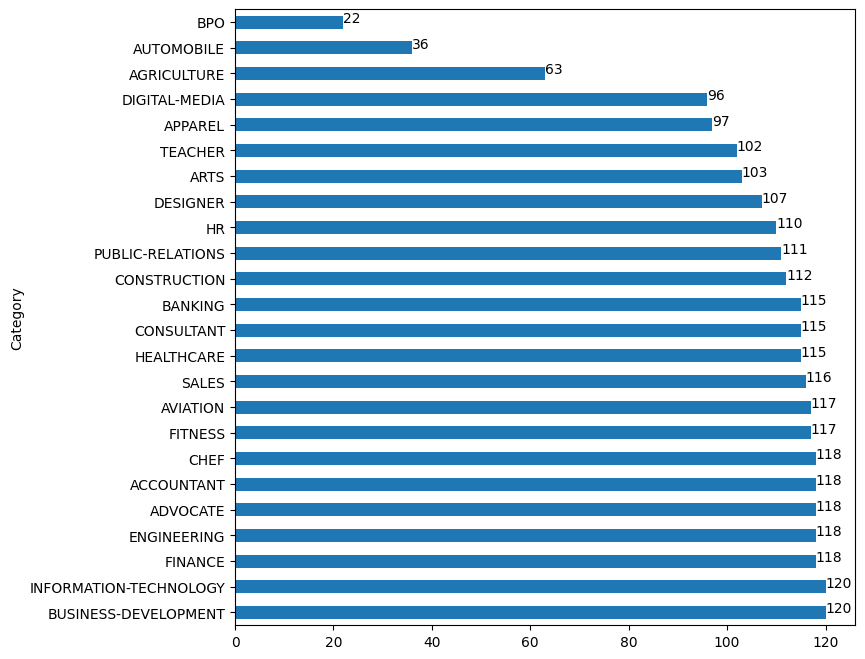

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
resume_df.Category.value_counts().plot(kind='barh')

for index, value in enumerate(resume_df.Category.value_counts().values):
    plt.text(value, index, str(value))

plt.show();

In [ ]:
from google.colab import files
resume_df.to_csv("extracted_data.csv", index=False)
files.download("extracted_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>